**Daniel Yu & Jordan Wang**

Spring 2026

CS 443: Bio-inspired Machine Learning

# Extension 3: Skip-gram word context

In this extension we use a trained Skip-gram network to predict context words around each target word. We train on IMDb train reviews, then evaluate context prediction behavior on IMDb test reviews.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from text_dataset_word import WordLevelDataset
from skipgram import Skipgram

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams.update({'font.size': 16})
np.set_printoptions(suppress=True, precision=4)

%load_ext autoreload
%autoreload 2

2026-05-01 16:17:08.909536: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-01 16:17:08.983769: I tensorflow/core/platform/cpu_feature_guard.cc:211] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Setup: Train Skip-gram on IMDb train split

For this extension, we train a smaller Skip\-gram model directly in this notebook so the experiment stays easy to run and compare. To make the code run faster while testing, we can lower N\_train\_reviews and epochs.


In [2]:
seed = 1
tf.random.set_seed(seed)
np.random.seed(seed)

N_train_reviews = 8000
context_win_sz = 2
embedding_dim = 96
epochs = 6
batch_size = 256
print_every = 5000

train_ds = WordLevelDataset(file_path='data/imdb_train.csv', context_win_sz=context_win_sz, verbose=True)
targets_int, contexts_int, vocab = train_ds.process(N_reviews=N_train_reviews)

vocab_sz = len(vocab)
word2ind = train_ds.get_word2ind_map()
ind2word = train_ds.get_ind2word_map()

print(f'Vocab size: {vocab_sz}')
print(f'Num training pairs: {len(targets_int)}')

Number of target words: 6796570
Number of context words: 6796570
Vocab size: 52726
Num training pairs: 6796570


2026-05-01 16:17:17.371662: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1385 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:00:03.0, compute capability: 8.9


---------------------------------------------------------------------------
Dense layer output(Dense_0) shape: [1, 52726]
Dense layer output(Embed_0) shape: [1, 96]
---------------------------------------------------------------------------


I0000 00:00:1777652239.806604     752 service.cc:145] XLA service 0x6407721f5170 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777652239.806641     752 service.cc:153]   StreamExecutor device (0): NVIDIA L4, Compute Capability 8.9
2026-05-01 16:17:19.827127: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-01 16:17:19.867077: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 90400
I0000 00:00:1777652239.981355     752 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Epoch 1/6, mini-batch 5000/159294, avg loss: 7.1510


Epoch 1/6, mini-batch 10000/159294, avg loss: 6.8965


Epoch 1/6, mini-batch 15000/159294, avg loss: 6.8367


...

Epoch 6/6, mini-batch 140000/159294, avg loss: 6.5134


Epoch 6/6, mini-batch 145000/159294, avg loss: 6.5187


Epoch 6/6, mini-batch 150000/159294, avg loss: 6.5148


Epoch 6/6, mini-batch 155000/159294, avg loss: 6.5171


Finished training after 6 epochs!


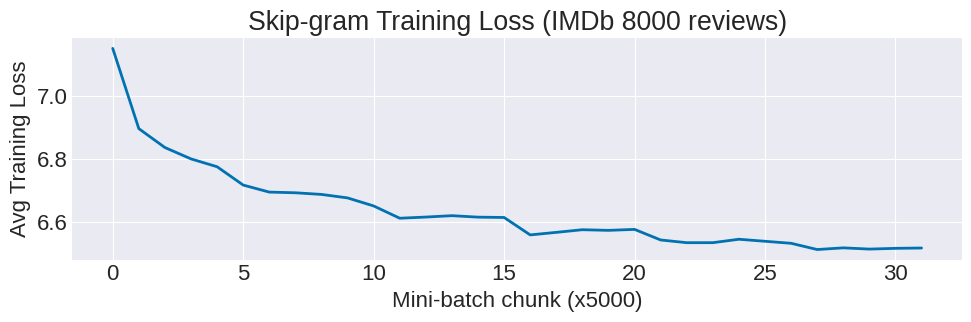

In [3]:
skip = Skipgram(input_feats_shape=(vocab_sz,), C=vocab_sz, embedding_dim=embedding_dim)
skip.compile(lr=5e-4)

loss_hist = skip.fit(
    targets_int, contexts_int,
    batch_size=batch_size,
    epochs=epochs,
    print_every=print_every,
    verbose=True
)

plt.figure(figsize=(10, 3.5))
plt.plot(loss_hist, linewidth=2)
plt.xlabel(f'Mini-batch chunk (x{print_every})')
plt.ylabel('Avg Training Loss')
plt.title(f'Skip-gram Training Loss (IMDb {N_train_reviews} reviews)')
plt.tight_layout()
plt.show()

## Build test corpus from IMDb test split

We will load and preprocess IMDb test data, then test context predictions on unseen text.


In [4]:
N_test_reviews = 1000

test_ds = WordLevelDataset(file_path='data/imdb_test.csv', context_win_sz=context_win_sz, verbose=False)
test_reviews = test_ds.load(N_reviews=N_test_reviews)
test_corpus = test_ds.make_corpus(test_reviews, min_sent_size=2)

print(f'Loaded test reviews: {len(test_reviews)}')
print(f'Test sentences in corpus: {len(test_corpus)}')
print('Example sentence:')
print(test_corpus[0][:20])

Loaded test reviews: 1000
Test sentences in corpus: 11713
Example sentence:
['what', 'i', 'enjoyed', 'most', 'in', 'this', 'film', 'was', 'the', 'scenery', 'of', 'corfu', 'being', 'greek', 'i', 'adore', 'my', 'country', 'and', 'i']


## Predict context words for a target word

Since this implementation trains with `target -> context`, we feed a target index and read top context probabilities from the output layer.

In [5]:
def predict_top_context_words(skip_net, target_word, word2ind_map, ind2word_map, top_k=10):
    if target_word not in word2ind_map:
        return []

    target_idx = word2ind_map[target_word]
    logits = skip_net(tf.constant([target_idx], dtype=tf.int32))[0]  # shape=(vocab_sz,)
    probs = tf.nn.softmax(logits)
    top_vals, top_inds = tf.math.top_k(probs, k=top_k)

    return [(ind2word_map[int(i)], float(v)) for i, v in zip(top_inds.numpy(), top_vals.numpy())]

def observed_context_words_in_sentence(sentence, target_word, window=2):
    observed = []
    for i, w in enumerate(sentence):
        if w == target_word:
            lo = max(0, i - window)
            hi = min(len(sentence), i + window + 1)
            observed.extend([sentence[j] for j in range(lo, hi) if j != i])
    return observed

In [6]:
target_word = 'movie'
top_k = 12

predicted = predict_top_context_words(skip, target_word, word2ind, ind2word, top_k=top_k)

# Find one test sentence that contains this target word and compare observed local context words
example_sentence = None
for sent in test_corpus:
    if target_word in sent:
        example_sentence = sent
        break

print(f'Target word: {target_word}')
print(f'Top {top_k} predicted context words:')
for w, p in predicted:
    print(f'  {w:15s} prob={p:.5f}')

if example_sentence is not None:
    observed = observed_context_words_in_sentence(example_sentence, target_word, window=context_win_sz)
    print('\nExample test sentence with target:')
    print(' '.join(example_sentence[:35]))
    print('\nObserved local context words in this sentence:')
    print(observed[:20])
else:
    print('No example sentence in selected test subset contained this target word.')

Target word: movie
Top 12 predicted context words:
  this            prob=0.00002
  the             prob=0.00002
  a               prob=0.00002
  is              prob=0.00002
  in              prob=0.00002
  of              prob=0.00002
  that            prob=0.00002
  and             prob=0.00002
  was             prob=0.00002
  to              prob=0.00002
  i               prob=0.00002
  with            prob=0.00002

Example test sentence with target:
macarthur is a great movie with a great story about a great man general douglas macarthur

Observed local context words in this sentence:
['a', 'great', 'with', 'a']


## Quantitative check on test pairs: Hit@K

For each test pair, we check whether the model can rank the real context word within its top\-K predictions for a given target word. We restrict this to words in the training vocabulary so the model is only evaluated on words it actually had a chance to learn.


Hit@1: 0.0861 (evaluated over 14719 test context pairs)


Hit@3: 0.1732 (evaluated over 14719 test context pairs)


Hit@5: 0.2254 (evaluated over 14719 test context pairs)


Hit@10: 0.3076 (evaluated over 14719 test context pairs)


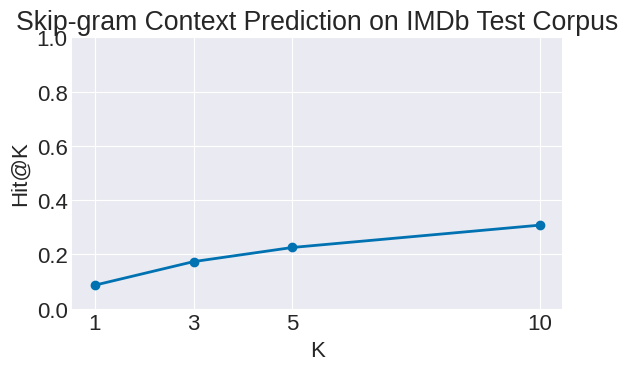

In [7]:
def evaluate_hit_at_k(skip_net, corpus, word2ind_map, top_k=10, window=2, max_targets=4000):
    hits = 0
    total = 0

    checked_targets = 0
    for sent in corpus:
        mapped = [w for w in sent if w in word2ind_map]
        if len(mapped) < 2:
            continue

        for i, target_word in enumerate(mapped):
            if checked_targets >= max_targets:
                break

            target_idx = word2ind_map[target_word]
            probs = tf.nn.softmax(skip_net(tf.constant([target_idx], dtype=tf.int32))[0])
            top_inds = tf.math.top_k(probs, k=top_k).indices.numpy().tolist()
            top_set = set(top_inds)

            lo = max(0, i - window)
            hi = min(len(mapped), i + window + 1)
            true_context_inds = [word2ind_map[mapped[j]] for j in range(lo, hi) if j != i]

            for c_idx in true_context_inds:
                total += 1
                if c_idx in top_set:
                    hits += 1

            checked_targets += 1

        if checked_targets >= max_targets:
            break

    return hits / total if total > 0 else 0.0, total

Ks = [1, 3, 5, 10]
hit_rates = []
totals = []

for K in Ks:
    hit_k, total_pairs = evaluate_hit_at_k(
        skip,
        test_corpus,
        word2ind,
        top_k=K,
        window=context_win_sz,
        max_targets=4000
    )
    hit_rates.append(hit_k)
    totals.append(total_pairs)
    print(f'Hit@{K}: {hit_k:.4f} (evaluated over {total_pairs} test context pairs)')

plt.figure(figsize=(6, 4))
plt.plot(Ks, hit_rates, marker='o', linewidth=2)
plt.xticks(Ks)
plt.ylim(0, 1)
plt.xlabel('K')
plt.ylabel('Hit@K')
plt.title('Skip-gram Context Prediction on IMDb Test Corpus')
plt.tight_layout()
plt.show()

## Extension 3 Summary

In this extension, I trained a Skip\-gram model on the IMDb training reviews and tested whether it could predict likely context words around target words from the test set.

The qualitative examples show the kinds of word relationships the model learned, while the Hit@K scores give a more concrete measure of prediction quality. The main takeaway is that the model can capture some useful context patterns, but it still struggles when words are rare, out of vocabulary, or used in more ambiguous ways.
